In [1]:
%load_ext autoreload
%autoreload 2

# Load libraries

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

import logging
from typing import Optional
import numpy.typing as npt

import pickle
from skopt import Optimizer

from mpl_toolkits.axes_grid1 import make_axes_locatable
from skopt.plots import plot_convergence, plot_evaluations, plot_objective

In [3]:
# Add path to bern3d_tools and bayesian module
sys.path.insert(1,"../../../bern3d_tools/")
import shared.utils as shared_utils
sys.path.insert(1,"../../../bern3d_tools/bayesian_optimization")
import bayesian_optimization as bo

In [4]:
# Define logger and logger level
logging.basicConfig()
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

# Visualize optimization

In [5]:
# Path to config file used
config_file = "../bayesian_optimization/config_npzd.yaml"
my_config = shared_utils.read_config_file(config_file, bo.ConfigParameters)

file_results = f"{my_config.work_directory}/bayesian_optimization/{my_config.tuning_target}_df.csv"
df = pd.read_csv(file_results, index_col=0)

df

,a_growth_diaz,a_growth_cocc,a_growth_diat,a_growth_other,graze_max,mort_zoo,pref_diaz,pref_cocc,pref_diat,pref_other,pref_det,pref_self,mae_dic_alk_po4_sio_no3_npp_poc_caco3_opal
NPZD_00_000,1.639796,2.060631,1.905858,1.975372,2.590357,2.941669,0.343330,0.103110,1.213467,0.560352,0.215647,1.099685,7.951476
NPZD_01_000,0.435207,2.265495,2.730865,0.951989,1.980268,0.982351,1.893920,1.199407,1.025223,1.487882,1.425694,0.664904,NaN
NPZD_02_000,0.948042,2.188248,0.897572,0.981732,2.892692,1.659370,0.948155,1.044663,1.881731,0.291255,1.203692,0.418969,NaN
NPZD_03_000,0.950377,0.285347,2.425430,1.058313,0.311922,0.993367,1.629578,1.084137,0.779427,1.377496,1.581693,1.409758,5.142563
NPZD_04_000,0.677822,2.633458,0.436419,1.553235,0.238560,0.122086,0.497879,0.915007,1.957416,0.560078,1.879693,1.251798,4.986314
...,...,...,...,...,...,...,...,...,...,...,...,...,...
NPZD_01_023,1.069056,2.640805,1.306190,2.907522,0.175403,1.087788,1.405010,0.454422,0.185784,1.548849,0.100865,1.346752,2.298841
NPZD_02_023,2.346942,0.335136,2.904002,0.667123,0.265726,0.010661,1.871194,1.533648,0.387161,0.131782,0.239870,1.927406,2.330224
NPZD_03_023,1.325389,0.151096,2.929538,0.626789,0.272130,0.951279,0.647771,1.041266,0.291360,0.587617,0.112255,1.693971,2.611894
NPZD_04_023,1.614441,1.038416,2.148800,1.889745,0.328283,2.977363,0.289807,1.117288,0.321379,1.313664,0.354091,0.791612,3.444809


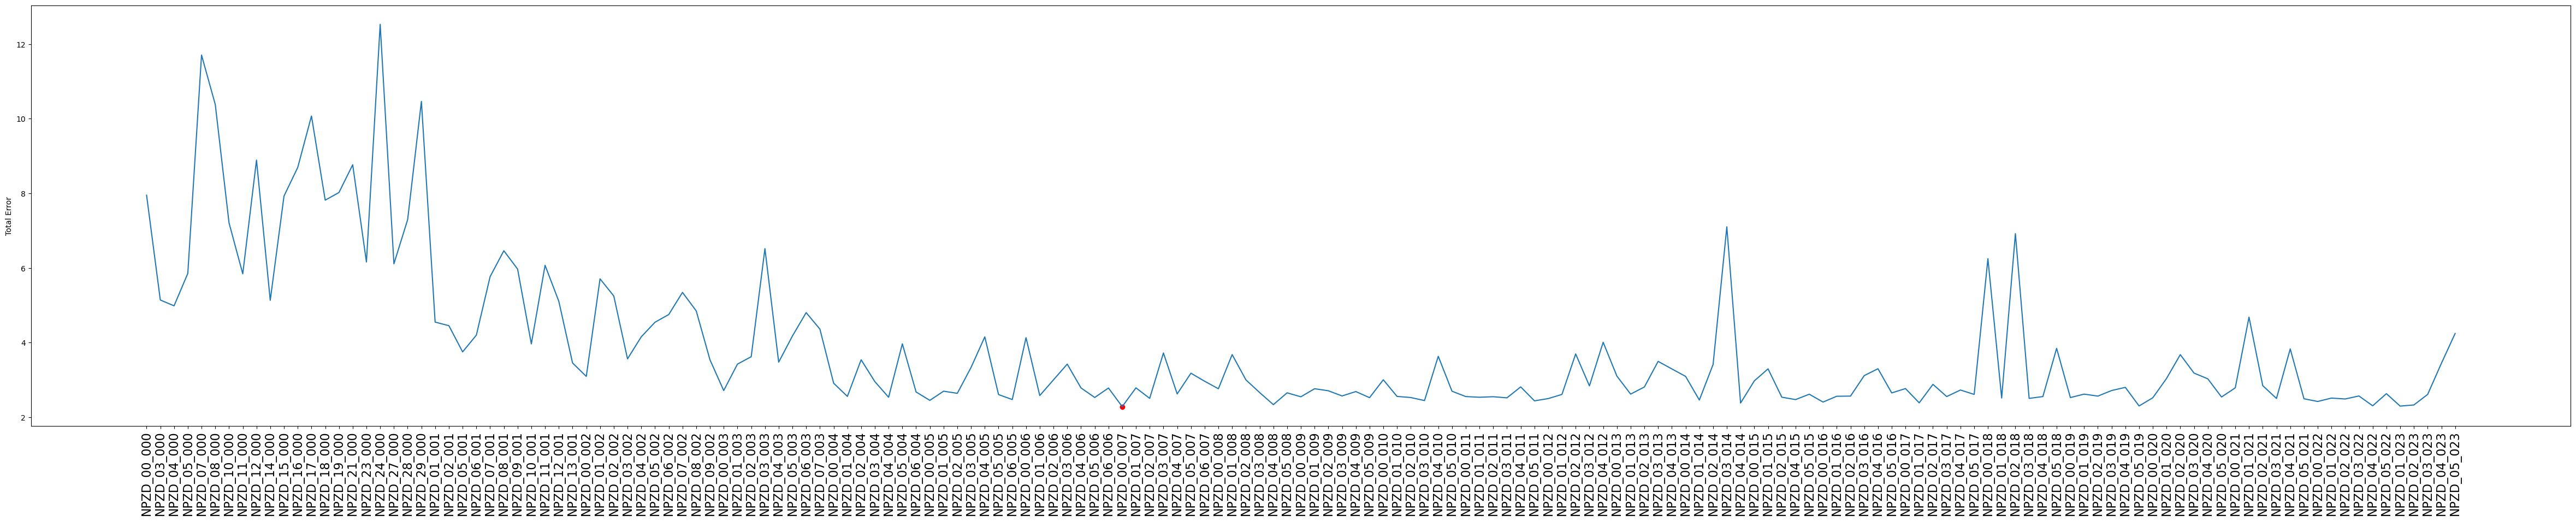

Best performing parameter set is: NPZD_00_007


a_growth_diaz                                 1.087943
a_growth_cocc                                 2.557407
a_growth_diat                                 2.025622
a_growth_other                                2.725499
graze_max                                     0.125002
mort_zoo                                      2.944743
pref_diaz                                     1.398540
pref_cocc                                     0.719913
pref_diat                                     0.104997
pref_other                                    1.561153
pref_det                                      0.165095
pref_self                                     1.515758
mae_dic_alk_po4_sio_no3_npp_poc_caco3_opal    2.285797
Name: NPZD_00_007, dtype: float64

In [6]:
fig, ax = plt.subplots(figsize=(60, 10))

data = df[f'mae_{my_config.tuning_target}'].dropna()

min_value = np.nanmin(data)
pos_min = np.argwhere(data == min_value)
ax.plot(np.arange(len(data)), data)
ax.scatter(pos_min, min_value, color='red')

ticks = data.index
ax.set_xticks(ticks=np.arange(len(ticks)), labels=ticks, rotation=90, fontsize=16)

ax.set_ylabel('Total Error')
plt.show()

winner = list(ticks)[pos_min.squeeze()]
print(f'Best performing parameter set is: {winner}')
df.loc[winner]

## Standard skopt plots

### Partial dependency plots

The following cell plots a 2D matrix with the partial dependency plots of the objective function. 
- The diagonal shows the influence of each seach-space dimension on the objective function.
- The plots below the diagonal show the effect on the objective function when varying two dimensions.

<Axes: >

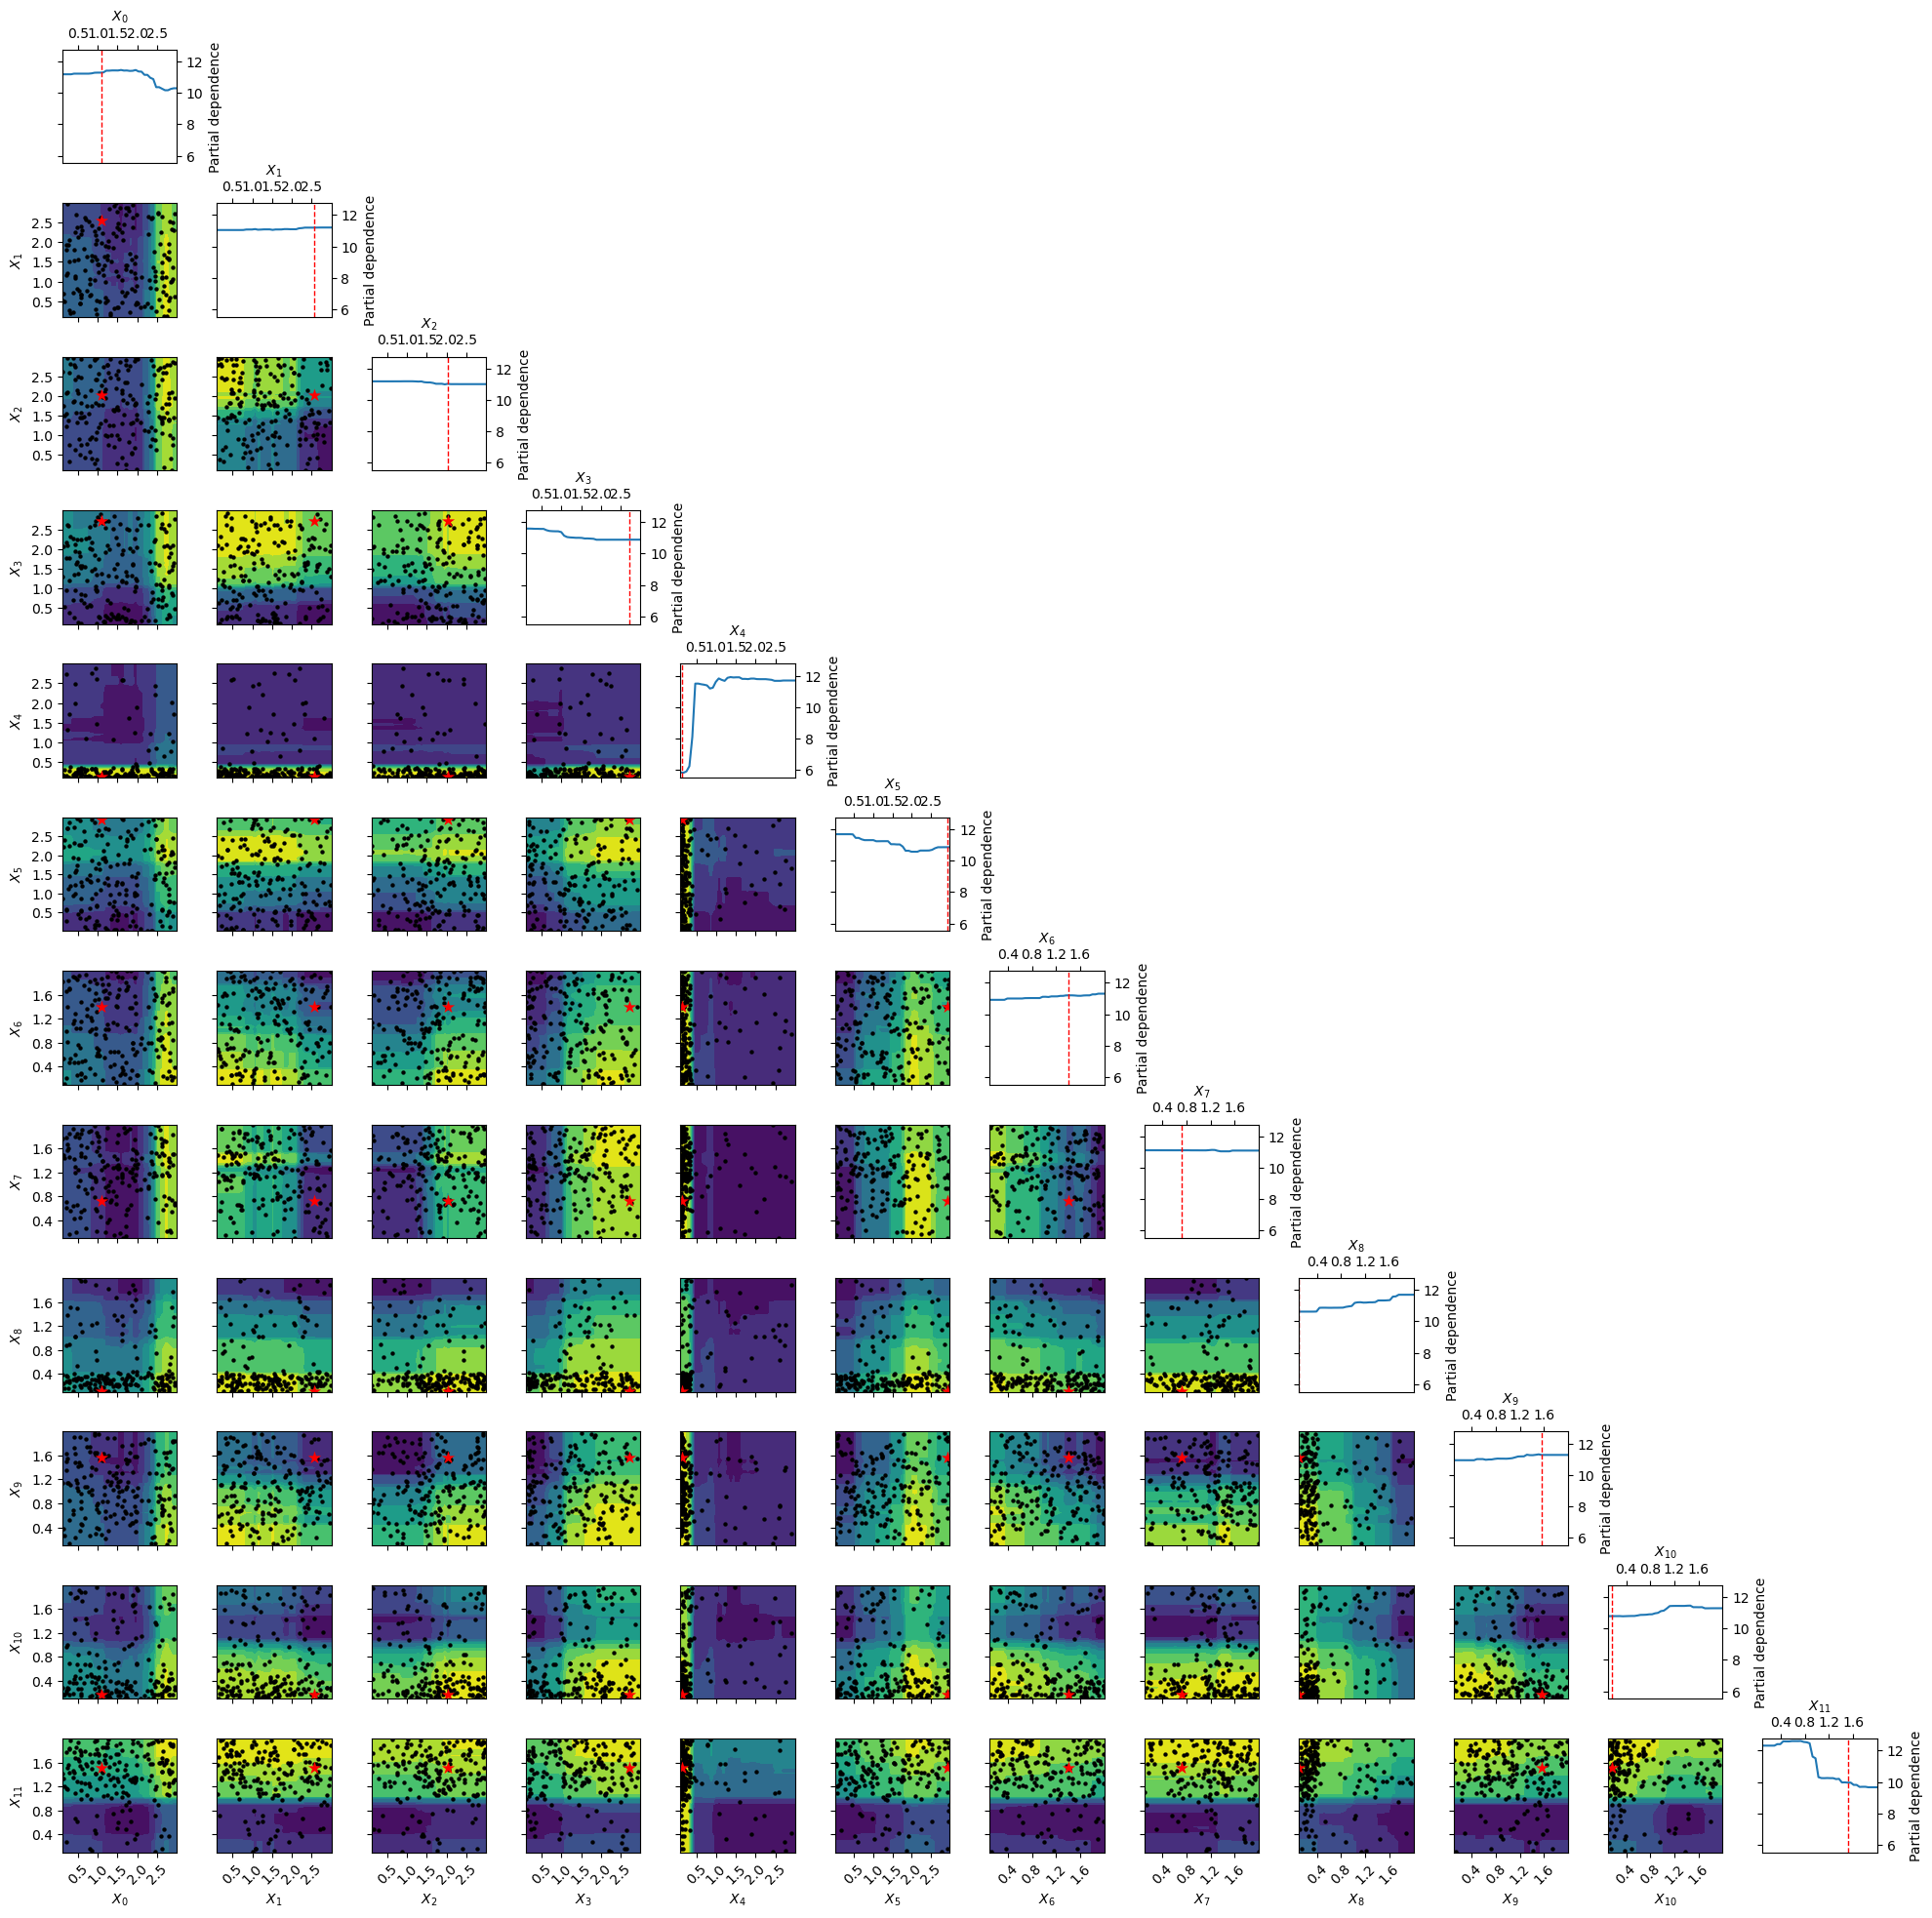

In [7]:
# Load the optimizer object
with open(f"{my_config.work_directory}/bayesian_optimization/optimizer.pkl", 'rb') as f:
    my_optimizer = pickle.load(f)

# ==================================================
# This plot might take very long!
# ==================================================

# plot the partial dependency plots
plot_objective(my_optimizer.get_result())

### Convergence plot

The following cell plots the **minimum error** or the value of the objective function as a function of the number of simulations.

<Axes: title={'center': 'Convergence plot'}, xlabel='Number of calls $n$', ylabel='$\\min f(x)$ after $n$ calls'>

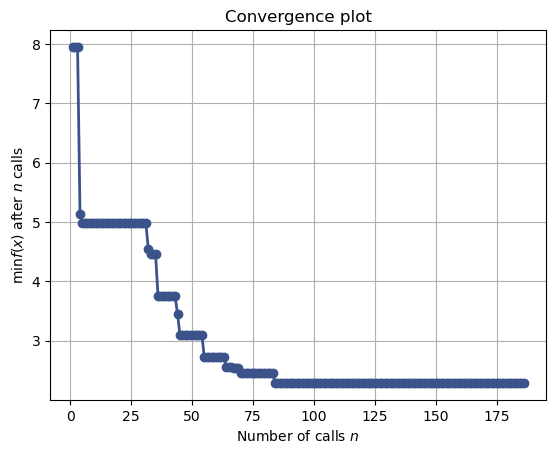

In [8]:
# Plot the target/error convergence
plot_convergence(my_optimizer.get_result())


### Evaluations

The following cell plots the order in which points were sampled during optimization. 
- The diagonal shows the histograms showing the distribution of samples for each search-space dimension.
- The plots below the diagonal are scatter-plots of the samples for all combinations of search space dimensions.

A red star shows the best performing parameter value.

<Axes: >

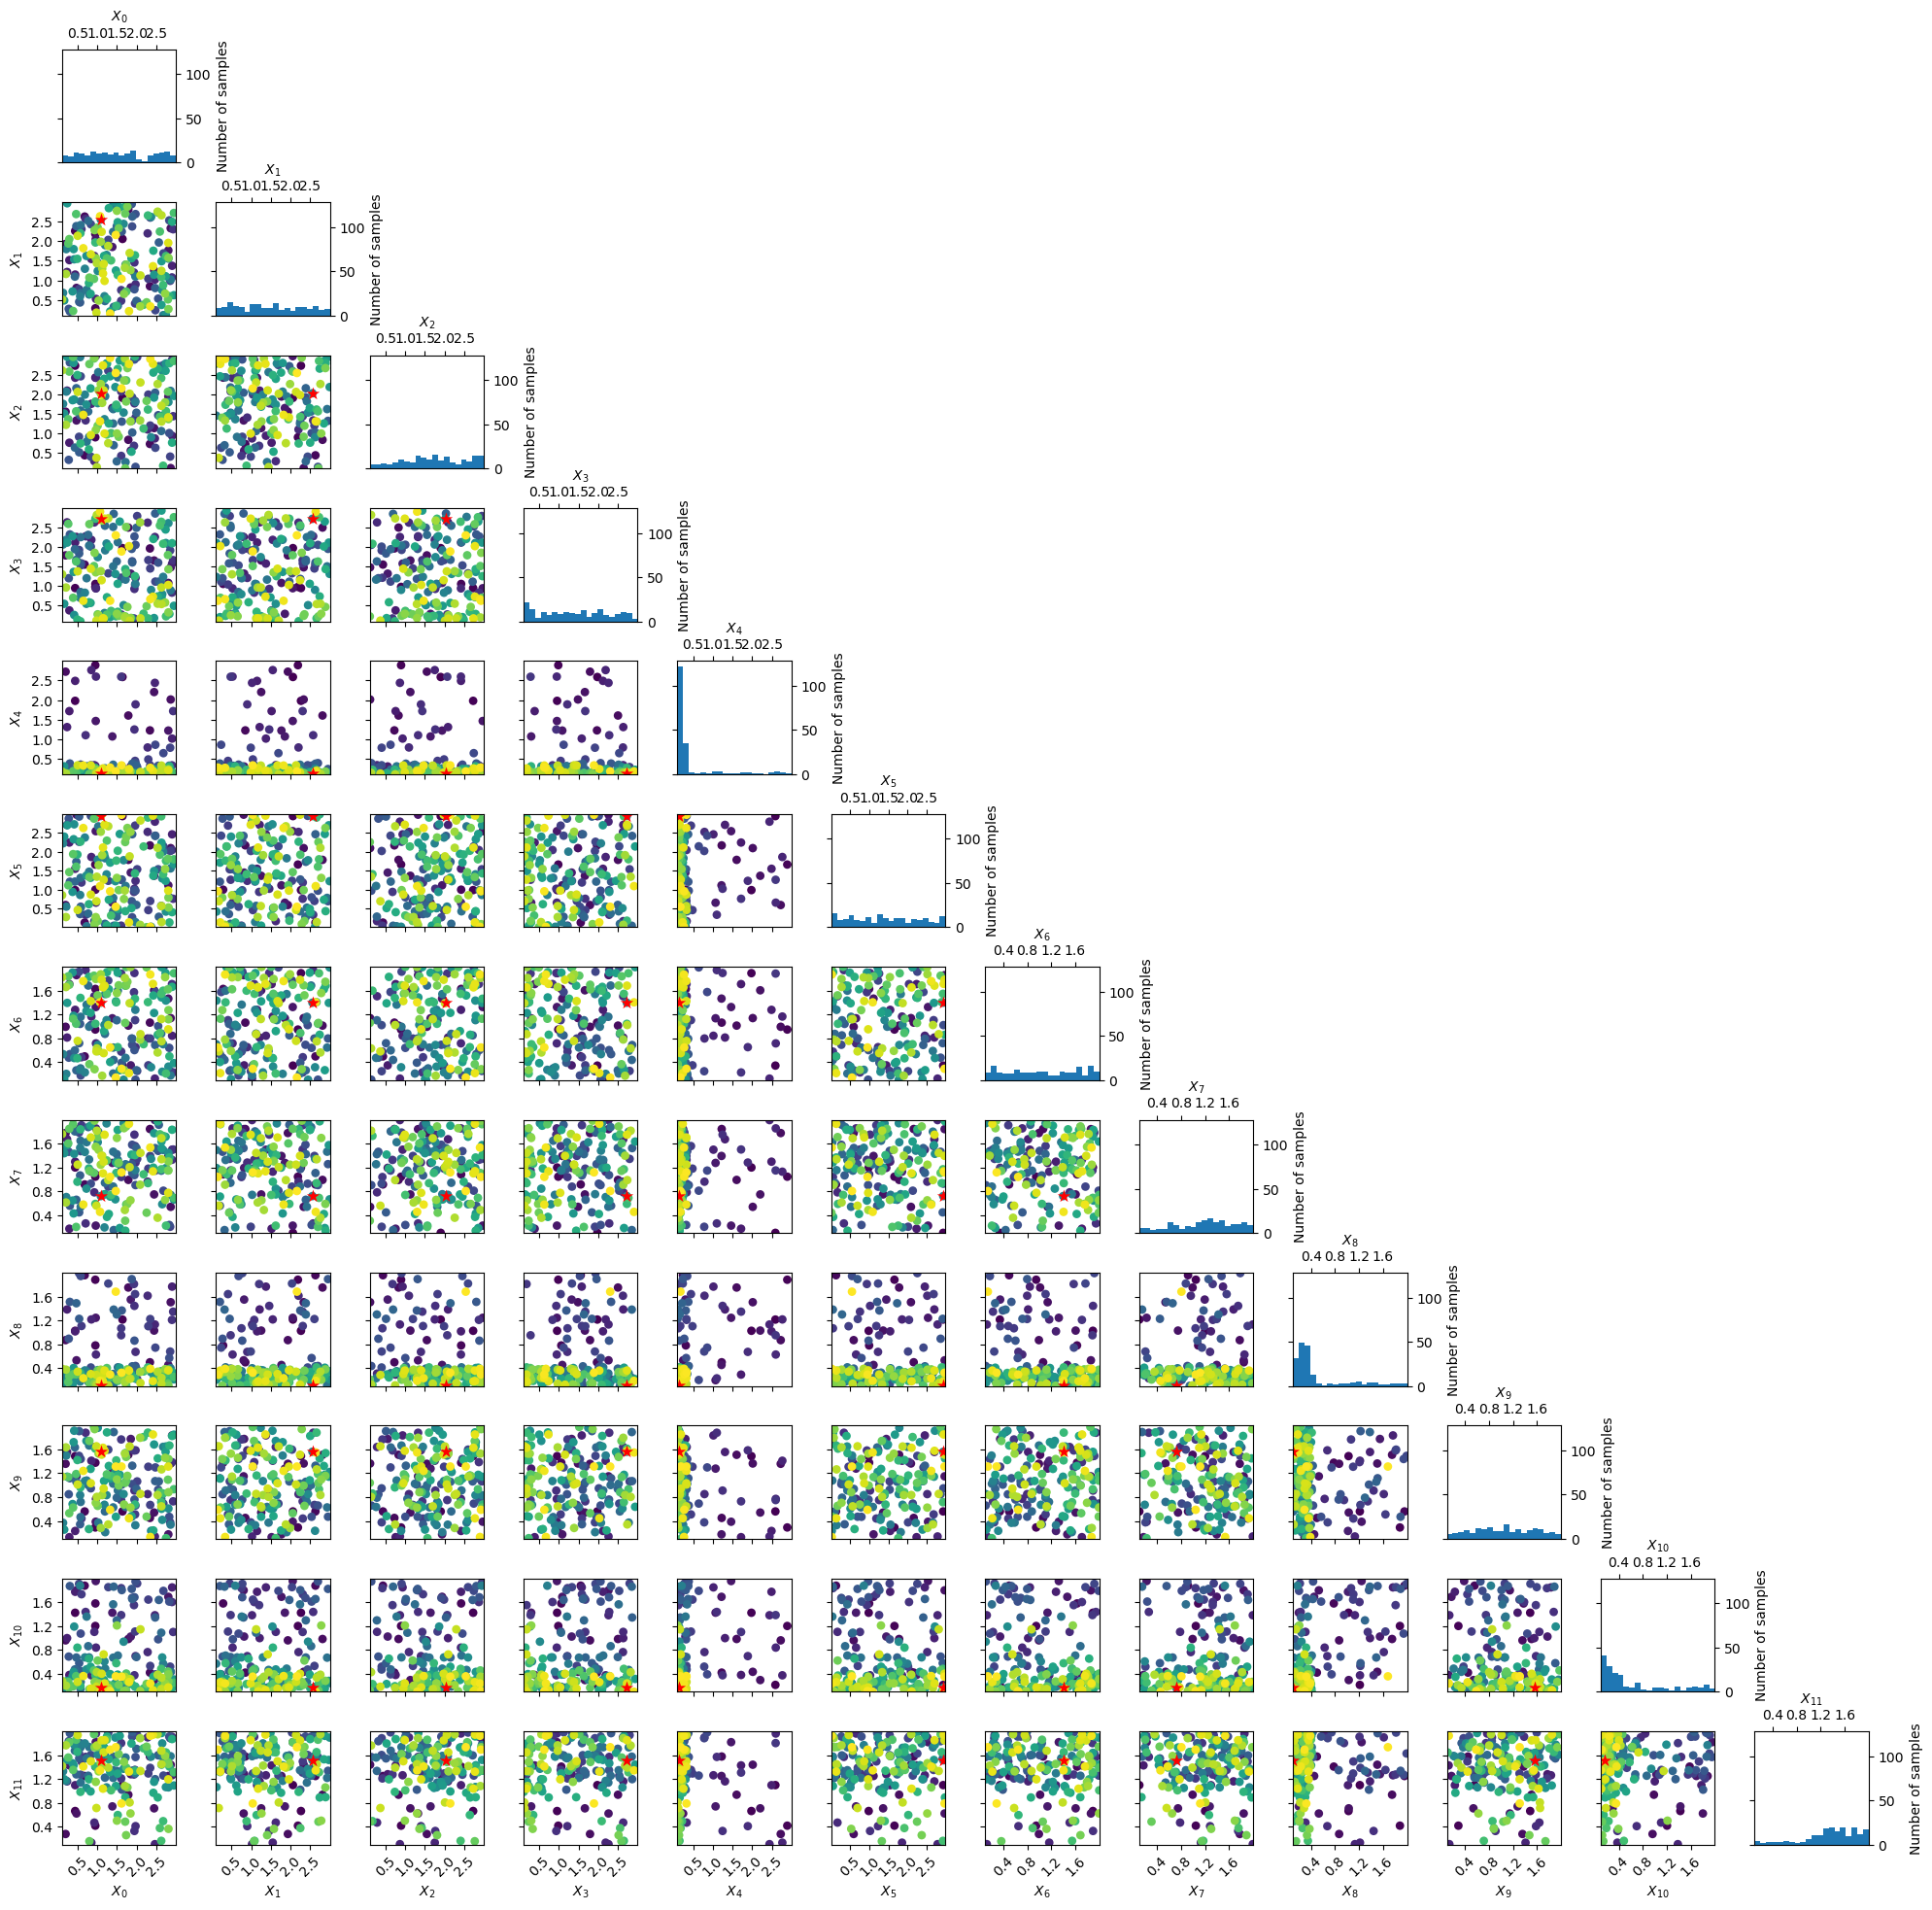

In [9]:
# plot the evaluation plots
plot_evaluations(my_optimizer.get_result())

## Compare results to standard simulation

**Note: The names of the variables need to be adapted to what was used in the simulation and observations.**

In [10]:
# ==================================================
# Define a standard simulation for the comparison
# ==================================================
reference_simulation = "/storage/scratch/users/uh24x373/bern3d_f90/results/Spinup3.00001765_full_ave.nc"
ds_reference = xr.open_dataset(reference_simulation, decode_times=False)

In [11]:
# ==================================================
# Choose variable to plot
# ==================================================
variable = 'no3'

results_dir = f"{my_config.work_directory}/results/"
simulation = f"{results_dir}{winner}.00001765_full_ave.nc"
ds_sim = xr.open_dataset(simulation, decode_times=False)

if os.path.exists(f"{my_config.work_directory}/run_{winner}"):
    file_obs = f"{my_config.work_directory}/run_{winner}/world_68x46.observations.nc"
else:
    file_obs = f"{my_config.work_directory}/run/world_68x46.observations.nc"
    
ds_obs = xr.open_dataset(file_obs, decode_times=False)

if variable == 'dic':
    label = '$\mu mol/kg$'
    var_sim = ds_sim.DIC*1000
    var_obs = ds_obs.dic
    var_sta = ds_reference.DIC*1000
    min_max = [1800, 2300]
elif variable == 'alk':
    label = '$\mu mol/kg$'
    var_sim = ds_sim.ALK*1000
    var_obs = ds_obs.alk
    var_sta = ds_reference.ALK*1000
    min_max = [2000, 2600]
elif variable == 'po4':
    label = 'mmol/kg'
    var_sim = ds_sim.PO4*1000
    var_obs = ds_obs.po4
    var_sta = ds_reference.PO4*1000
    min_max = [0, 3]
elif variable == 'no3':
    label = 'mmol/kg'
    var_sim = ds_sim.NO3*1000
    var_obs = ds_obs.no3
    var_sta = ds_reference.NO3*1000
    min_max = [0, 30]
elif variable == 'sio':
    label = 'mmol/kg'
    var_sim = ds_sim.SiO*1000
    var_obs = ds_obs.sio
    var_sta = ds_reference.SiO*1000
    min_max = [0, 90]

/scratch/local/32020687/ipykernel_521202/3552792310.py:39: RuntimeWarning: Mean of empty slice
  data_plot = np.nanmean(var_sim[-1,:,:,:].values - var_obs[:,:,:].values, axis=0)
/scratch/local/32020687/ipykernel_521202/3552792310.py:52: RuntimeWarning: Mean of empty slice
  data_plot = np.nanmean(var_sta[-1,:,:,:].values - var_obs[:,:,:].values, axis=0)


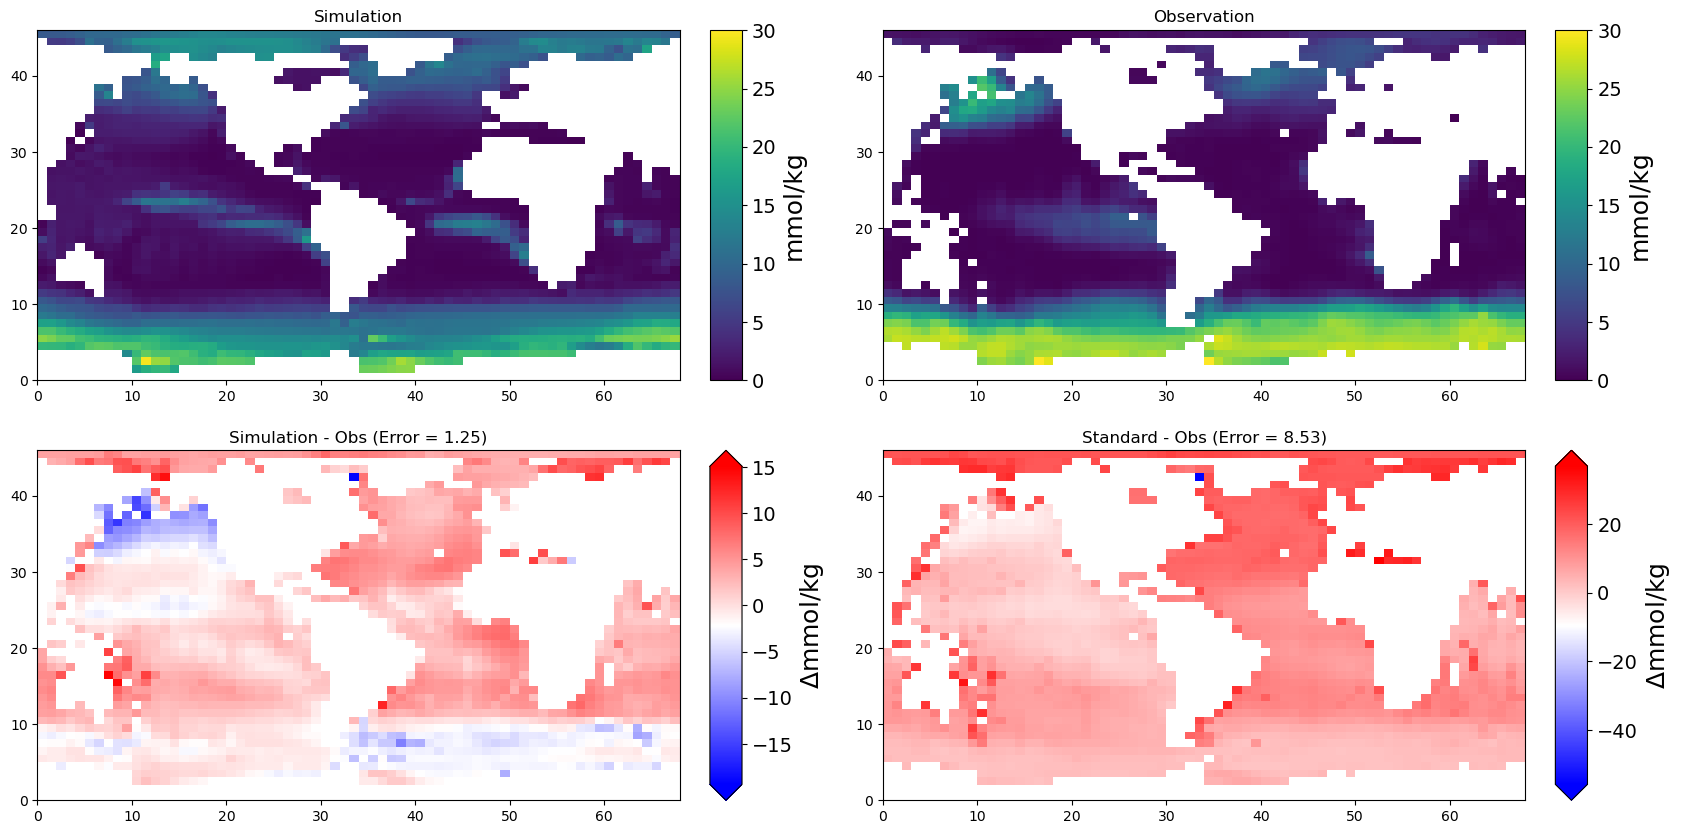

In [12]:
# ==================================================
# Choose depth to plot
# ==================================================
depth = 0

plt.style.use('default')
fig = plt.figure(figsize=(20, 10))
props = dict(shape=[2, 2], fig=fig)
axes = [
    plt.subplot2grid(**props, loc=(0, 0), rowspan=1),
    plt.subplot2grid(**props, loc=(0, 1), rowspan=1),
    plt.subplot2grid(**props, loc=(1, 0), rowspan=1),
    plt.subplot2grid(**props, loc=(1, 1), rowspan=1),
]

# ==================================================
# Winner simulation
# ==================================================
ax = axes[0]
contour = ax.pcolormesh(var_sim[-1,depth,:,:], shading="auto", cmap='viridis', vmin=min_max[0], vmax=min_max[1]) 

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.3)
cb = fig.colorbar(contour, orientation='vertical', cax=cax)
cb.ax.tick_params(labelsize=14)
cb.set_label(label, fontsize=18)
ax.set_title('Simulation')

# ==================================================
# Observation
# ==================================================
ax = axes[1]
contour = ax.pcolormesh(var_obs[depth,:,:], shading="auto", cmap='viridis', vmin=min_max[0], vmax=min_max[1]) 

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.3)
cb = fig.colorbar(contour, orientation='vertical', cax=cax)
cb.ax.tick_params(labelsize=14)
cb.set_label(label, fontsize=18)
ax.set_title('Observation')

# ==================================================
# Average error between simulation and observations
# ==================================================
ax = axes[2]

data_plot = np.nanmean(var_sim[-1,:,:,:].values - var_obs[:,:,:].values, axis=0)

contour = ax.pcolormesh(data_plot, shading="auto", cmap='bwr') 
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.3)
cb = fig.colorbar(contour, orientation='vertical', cax=cax, extend='both')
cb.ax.tick_params(labelsize=14)
cb.set_label(f'$\Delta${label}', fontsize=18)
ax.set_title(f"Simulation - Obs (Error = {np.nanmean(data_plot):.2f})")

# ==================================================
# Average error between reference and observations
# ==================================================
ax = axes[3]

data_plot = np.nanmean(var_sta[-1,:,:,:].values - var_obs[:,:,:].values, axis=0)

contour = ax.pcolormesh(data_plot, shading="auto", cmap='bwr') 
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.3)
cb = fig.colorbar(contour, orientation='vertical', cax=cax, extend='both')
cb.ax.tick_params(labelsize=14)
cb.set_label(f'$\Delta${label}', fontsize=18)
ax.set_title(f"Standard - Obs (Error = {np.nanmean(data_plot):.2f})")


plt.show()